# 17-Qubit Surface-Code Chip (Wallraff group, ETH Zurich)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/tutorials%2FAppendix%20C%20Circuit%20examples%2FF.%20Small-quantum-chips%2F53-Wallraff_17Qubit_SurfaceCode.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=tutorials%2FAppendix%20C%20Circuit%20examples%2FF.%20Small-quantum-chips%2F53-Wallraff_17Qubit_SurfaceCode.ipynb)

> 💡 **Running in Colab or Binder?** Uncomment the install cell below. The notebook runs headless there — no Qt, no Ansys, about a minute end to end. On a desktop with the GUI installed, it also opens the chip in `MetalGUI` and updates it after every stage.

In 2022, the Quantum Device Lab at ETH Zurich ran repeated rounds of quantum error correction on a distance-three surface code — seventeen superconducting qubits on one die ([Krinner *et al.*, *Nature* 2022](https://doi.org/10.1038/s41586-022-04566-8)). In this notebook you build that chip in Quantum Metal, from the bare die to the last feedline, and check the design after every step.

**What you'll learn**

- how a surface-code processor is laid out: data and auxiliary qubits, couplers, control lines, readout with Purcell filters, multiplexed feedlines;
- how to draw a line that follows a known path with `PolylineCPW`, and connect to it partway along with *taps*;
- how to carry one line over another with an `Airbridge`;
- how to run Metal's design-rule check after every stage, including the shape rules that catch hairpins, self-crossings and unterminated line ends;
- how to export the chip to GDS, and how to change it and see the check respond.

| | |
|---|---|
| Qubits | 17 transmons: 9 data, 8 auxiliary |
| Die | 14.4 mm square, 48 wire-bond launchpads |
| Readout | 17 quarter-wave resonators, 17 Purcell filters, 4 feedlines |
| Components | 348 |
| Run time | about 1 minute |

## The device, and thanks

The chip is the design of the [Quantum Device Lab](https://qudev.phys.ethz.ch/) of Andreas Wallraff at ETH Zurich, used in S. Krinner, N. Lacroix, A. Remm *et al.* [1] and, in a device of the same design, for lattice surgery by I. Besedin, M. Kerschbaum *et al.* [2]. It builds on the group's earlier seven-qubit surface-code work [3] and on their multiplexed readout with individual Purcell filters [4, 5].

**Thank you** to Andreas Wallraff and the Quantum Device Lab for sharing this design openly — in the [lecture slides](https://polybox.ethz.ch/index.php/s/CnsHoKWW6xQKZAA) and in the talks [here](https://www.youtube.com/watch?v=floIDDd6ZXA), [here](https://www.youtube.com/watch?v=CgNz4wsD0oI), and at the Quantum Device Workshop ([lecture](https://www.youtube.com/watch?v=0r1YPMcmuFU)). Every position and path in this notebook was measured from the micrographs in those slides.

> ⚠️ **A mockup, not a mask.** This is a reconstruction for learning, and it is not perfect. Dimensions the images cannot resolve are chosen; each junction is a single junction standing in for the device's SQUID; and line crossings are drawn as airbridges, where the device uses integrated crossovers. The full list is under *Known issues* at the end.

> 🤖 **Rebuilt by AI agents, on top of Quantum Metal**
>
> The layout was reconstructed by AI coding agents working through Metal's Python API, with a person reviewing every stage: measuring the die from the slide images, writing the builder, and fixing what the design-rule check found.
>
> Reproducing a published device is a test, not the goal: the answer is known, so every mistake shows. The goal is designing *new* chips with AI — starting from a specification (qubits, connectivity, frequencies) and laying out, checking and simulating in Metal. That workflow is written up as the [`chip-design`](https://github.com/qiskit-community/qiskit-metal/blob/main/.claude/skills/chip-design/SKILL.md) agent skill. This notebook is a small, complete run of its core loop: build in stages, check every stage, change something, check again.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

### Setup

**GUI or headless.** `qm.gui(design)` opens the desktop `MetalGUI` when Qt and a display are available, and falls back to an inline headless viewer otherwise (Colab, Binder, a server). Set `HEADLESS` to choose yourself: `True` for inline figures, `False` to require the desktop GUI. In the desktop GUI each stage is drawn in the GUI window and a screenshot of it lands in the notebook; headless, Metal draws an inline figure instead. The outputs saved in this notebook, and shown in the docs, come from a headless run.

The builder (`wallraff_17q.py`) and the measured geometry (`geometry.json`) live in `resources/wallraff_17q/` beside this notebook. Colab opens a notebook on its own, so the cell fetches them if they are missing.

In [2]:
import sys
import tempfile
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

import qiskit_metal as qm
from qiskit_metal.validation import DEFAULT_RULES, SHAPE_RULES, validate

warnings.filterwarnings("ignore", category=FutureWarning)

HEADLESS = None  # None: desktop GUI if available; True: headless; False: desktop GUI

RES = Path("resources/wallraff_17q")
if not RES.exists():
    RES.mkdir(parents=True)
    base = ("https://raw.githubusercontent.com/qiskit-community/qiskit-metal/main/"
            "tutorials/Appendix%20C%20Circuit%20examples/F.%20Small-quantum-chips/"
            "resources/wallraff_17q/")
    for f in ("wallraff_17q.py", "geometry.json", "chip_inspect.py"):
        urllib.request.urlretrieve(base + f, RES / f)
sys.path.insert(0, str(RES))

import wallraff_17q as chip
from chip_inspect import inspect_sites

## Build it one layer at a time

Six stages, each a function in the builder. After every stage we draw the design and run the design-rule check, so a finding points straight at the stage that caused it.

The check runs Metal's default rules plus `SHAPE_RULES`, which look at the shape of each single line: a line crossing itself, a hairpin turn, a corner rounded less than was asked for, and a line end left unconnected.

In [3]:
RULES = [*DEFAULT_RULES, *SHAPE_RULES]


def show(design, xlim=(-7.3, 7.3), ylim=(-7.3, 7.3), size=7):
    """Draw the design zoomed to a window in mm: in the GUI if open, else inline."""
    if DESKTOP_GUI:
        gui.rebuild()
        gui.canvas.zoom_to_rectangle((xlim[0], ylim[0], xlim[1], ylim[1]))
        gui.screenshot(name=str(Path(tempfile.gettempdir()) / "wallraff_17q_gui"))
        return
    fig = qm.view(design)
    fig.set_size_inches(size, size * (ylim[1] - ylim[0]) / (xlim[1] - xlim[0]))
    ax = fig.axes[0]
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    display(fig)


def check(design):
    """Count components and run the design-rule check."""
    print(f"{len(design.components)} components")
    print(validate(design, rules=RULES).report())


design = chip.new_design()
gui = qm.gui(design, force_headless=HEADLESS)
DESKTOP_GUI = not isinstance(gui, qm.MetalGUIHeadless)
print("desktop MetalGUI" if DESKTOP_GUI else "headless: inline figures")

headless: inline figures


### 1. Die and launchpads

A 14.4 mm die with 48 wire-bond launchpads, twelve per edge on a 1 mm pitch. Six carry no line on the device; they are placed anyway, as they are on the die. Every launchpad is named after what it serves — `LP_flux_D5`, `LP_drive_D5`, `LP_feed_NE_N` or `LP_spare_...` — so you can find any line by name.

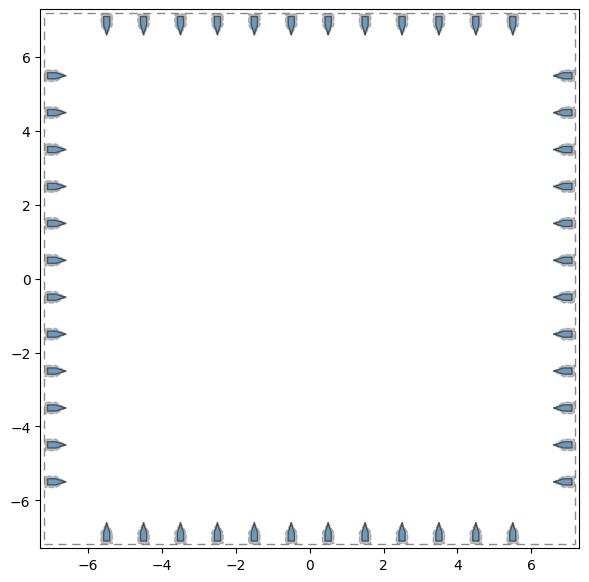

48 components
Design rules passed (11 rules ran, no findings).


In [4]:
chip.stage_launchpads(design)
show(design)
check(design)

### 2. Qubits

Seventeen star-shaped transmons (`StarQubit`), scaled to the measured island: an etched pocket about 0.32 mm across. Data qubits are named `D1`–`D9`; the auxiliary qubits that measure the stabilizers are `X1`–`X4` and `Z1`–`Z4`.

Each qubit is laid out like the device qubit in the close-up in the slides: five pads about 72° apart — the readout pad and four coupler pads — and the junction on the island arm between the readout pad and a coupler pad, facing the flux line. With the junction at 0°, the readout pad sits at 36° and the coupler pads at −36°, 108°, 180° and −108° (mirrored on qubits whose readout is on the other side). The device measures 42°, 112°, 180°, 252° and 325°. Qubits on the edge of the lattice keep their unused pads, as on the device.

> 👀 **Watch the angles.** `StarQubit` places each connector's pin 90° behind its `rotation_*` option, so the builder converts compass angles with `arm_rotation`; the junction's `rotation_jj` follows the same rule. Rather than trust that, the cell reads the *built* pins and junctions back and compares them with the layout.

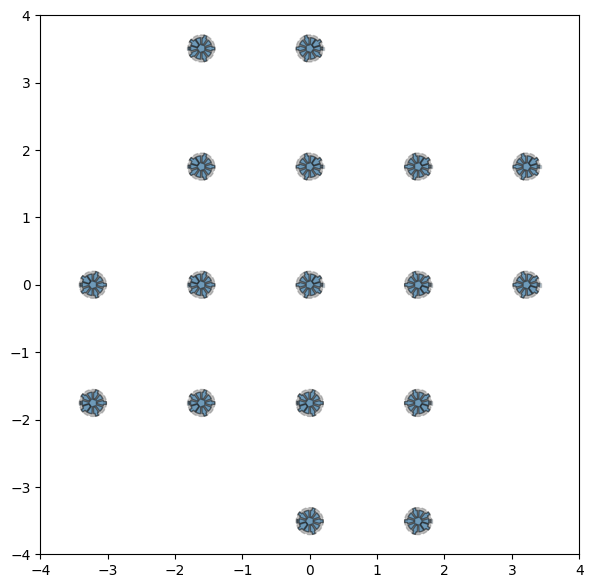

pads and junction where the layout puts them, all 17 qubits: True
D1: {'pin_cpl1': 324, 'pin_cpl2': 108, 'pin_cpl3': 180, 'pin_cpl4': 252, 'pin_rdout': 36, 'jj': 0}
65 components
Design rules passed (11 rules ran, no findings).


In [5]:
chip.stage_qubits(design)
show(design, xlim=(-4, 4), ylim=(-4, 4))

built = chip.pin_directions(design)
bad = [q for q in chip.QUBITS if built[q] != chip.expected_pin_directions(q)]
print("pads and junction where the layout puts them, all 17 qubits:", not bad)
print("D1:", built["D1"])
check(design)

### 3. Lattice couplers

One coupler for every pair of nearest neighbors — this is the surface code's stabilizer graph. A data qubit has two, three or four neighbors, depending on whether it sits at a corner, an edge or the center.

The couplers follow measured paths, so they are drawn with `PolylineCPW`, which draws exactly the points it is given instead of routing. Each line leaves its qubit pin straight, along the pin's direction, for 40 µm, so the line meets the pad square-on and its end is flush with it; then it follows the trace. The coupler toward the neighbor on the flux-line side leaves its pad 36° off that neighbor's direction, to make room for the junction, and bends back toward it — the jog you can see on the device.

> ℹ️ From here on the check warns that the ground plane is split: the four couplers around each plaquette fence in an island of ground. On the device, airbridges tie those islands to the rest of the ground plane. The rule sees only metal on the ground layer, and says so.

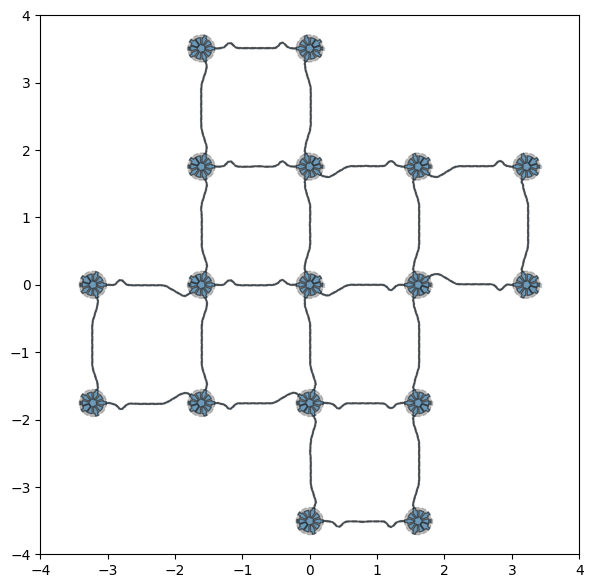

89 components
1 finding(s) from 11 rule(s): 0 error(s), 1 warning(s)
  [warning] ground-continuity: ground plane on layer 1 is split into 9 disconnected regions (mm^2: 176.700, 2.679, 2.617, 2.602, ...); confirm airbridges or vias tie them together -- this check sees only same-layer metal  @ (0.8200, -2.7438)


In [6]:
chip.stage_couplers(design)
show(design, xlim=(-4, 4), ylim=(-4, 4))
check(design)

### 4. Flux and drive lines

Each qubit gets a flux line from its own launchpad, ending in a short to ground beside the SQUID, and a drive line ending open beside the island.

The ends matter. The drive line couples capacitively, so its end must be open. A coplanar line whose end is simply left unconnected butts into the ground plane — on the wafer, that is a short. So every line end is terminated on purpose, and the `dangling-end` rule checks that none were forgotten.

Where a line crosses one drawn earlier, it is cut and carried over on an `Airbridge`. The bridge's pins `a` and `b` connect to the two cut ends, and the bridge metal sits on its own layer, so the crossing is not a short. (The device uses integrated crossovers here; the airbridge stands in for them.)

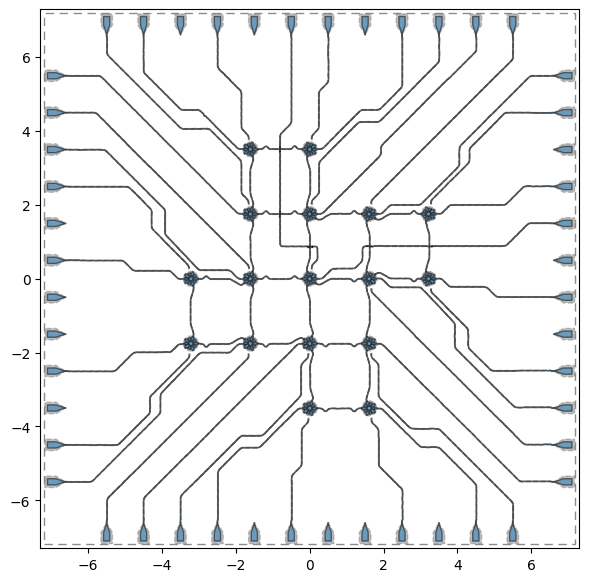

5 airbridges so far
167 components


1 finding(s) from 11 rule(s): 0 error(s), 1 warning(s)
  [warning] ground-continuity: ground plane on layer 1 is split into 9 disconnected regions (mm^2: 173.330, 2.627, 2.617, 2.602, ...); confirm airbridges or vias tie them together -- this check sees only same-layer metal  @ (-1.1961, 0.9126)


In [7]:
chip.stage_control_lines(design)
show(design)
bridges = [n for n in design.components if n.startswith("AB")]
print(f"{len(bridges)} airbridges so far")
check(design)

### 5. Readout resonators, Purcell filters and their couplers

Every qubit has its own readout resonator and its own Purcell filter, both quarter-wave lines [4]. The resonator is open at the qubit, where a triangular pad couples to the island, and shorted at its far end. The filter is shorted at one end and open at the other, where it couples to the feedline. The filter lets the readout signal out quickly while keeping the qubit from decaying through the same path.

Two small capacitors do the coupling:

- **Resonator–filter coupler**: a pad on each line, facing across a gap midway between them — `CapNInterdigital` with two fingers of zero length. It connects to *taps*: pins partway along each `PolylineCPW`, so each joint is a real, registered connection.
- **Filter–feedline coupler**: `CapFingerInFrame`, a frame electrode around a single finger. Its cross-section is the same on all 17; its length is set per qubit, and sets how strongly that filter couples to the feedline.

> ✅ **A sanity check on the tracing.** The traced resonator lengths track the readout frequencies reported in the paper (6.77–7.55 GHz): the shorter resonators belong to the higher-frequency auxiliary qubits.

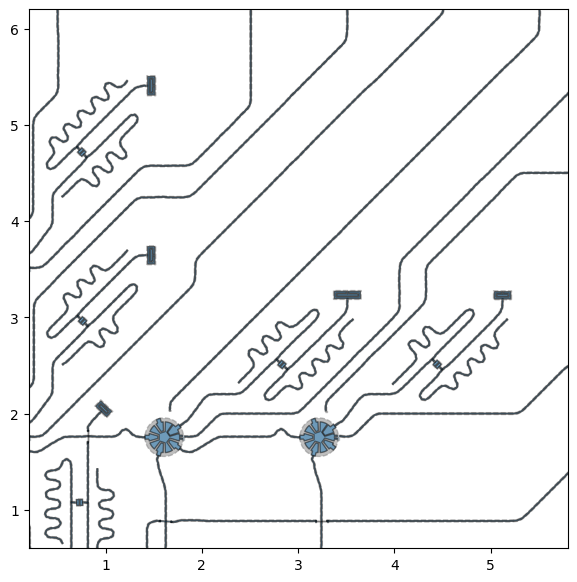

271 components


1 finding(s) from 11 rule(s): 0 error(s), 1 warning(s)
  [warning] ground-continuity: ground plane on layer 1 is split into 9 disconnected regions (mm^2: 170.751, 2.617, 2.602, 2.597, ...); confirm airbridges or vias tie them together -- this check sees only same-layer metal  @ (1.1888, 0.8377)


In [8]:
chip.stage_readout(design)
show(design, xlim=(0.2, 5.8), ylim=(0.6, 6.2))
check(design)

### 6. Feedlines and input capacitors

Four feedlines, one per quadrant, each reading out four or five qubits. Each runs from a launchpad on one edge to a launchpad on the neighboring edge, starts with a series input capacitor (the same `CapFingerInFrame` cell), and taps off a short stub to the finger of every filter coupler in its group.

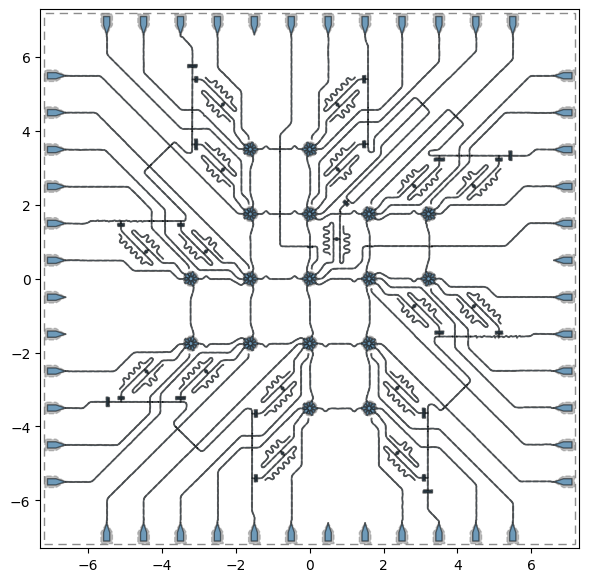

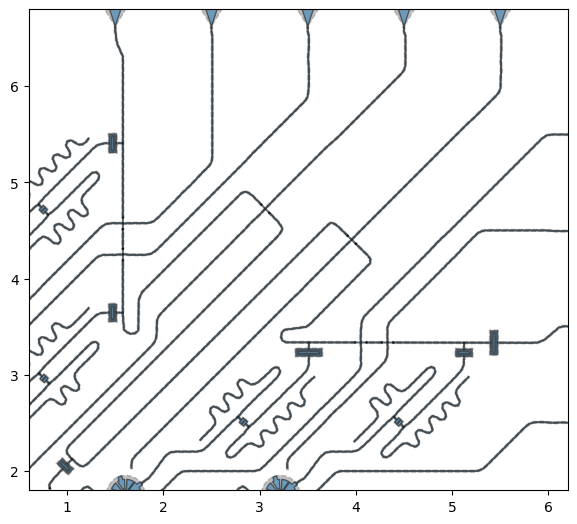

348 components


1 finding(s) from 11 rule(s): 0 error(s), 1 warning(s)
  [warning] ground-continuity: ground plane on layer 1 is split into 9 disconnected regions (mm^2: 169.762, 2.617, 2.602, 2.597, ...); confirm airbridges or vias tie them together -- this check sees only same-layer metal  @ (1.1888, 0.8377)


In [9]:
chip.stage_feedlines(design)
show(design)
show(design, xlim=(0.6, 6.2), ylim=(1.8, 6.8))
check(design)

## The finished chip 🎉

Every rule passes. The one warning is the ground islands from step 3.

In [10]:
from collections import Counter

kinds = Counter("qubit" if n in chip.QUBITS else n.split("_")[0] for n in design.components)
for k in sorted(kinds):
    print(f"  {k:10s} {kinds[k]:3d}")
check(design)

  AB           2
  ABD          3
  ABF         24
  ABP          1
  CPL         24
  DRIVE       20
  DRIVEOPEN   17
  FEED        28
  FEEDCAP      4
  FEEDIN       4
  FLUX        19
  FLUXSHORT   17
  LP          48
  PUCAP       17
  PURCELL     18
  PUSHORT     17
  PUSTUB      17
  RO          17
  ROSHORT     17
  RPCAP       17
  qubit       17
348 components


1 finding(s) from 11 rule(s): 0 error(s), 1 warning(s)
  [warning] ground-continuity: ground plane on layer 1 is split into 9 disconnected regions (mm^2: 169.762, 2.617, 2.602, 2.597, ...); confirm airbridges or vias tie them together -- this check sees only same-layer metal  @ (1.1888, 0.8377)


### Inspect every qubit

One zoomed panel per qubit: the island, its couplers, and where the flux and drive lines stop. Mistakes that vanish in a whole-chip view — a line ending on the wrong side, a gap that differs from qubit to qubit — stand out when all seventeen sit side by side.

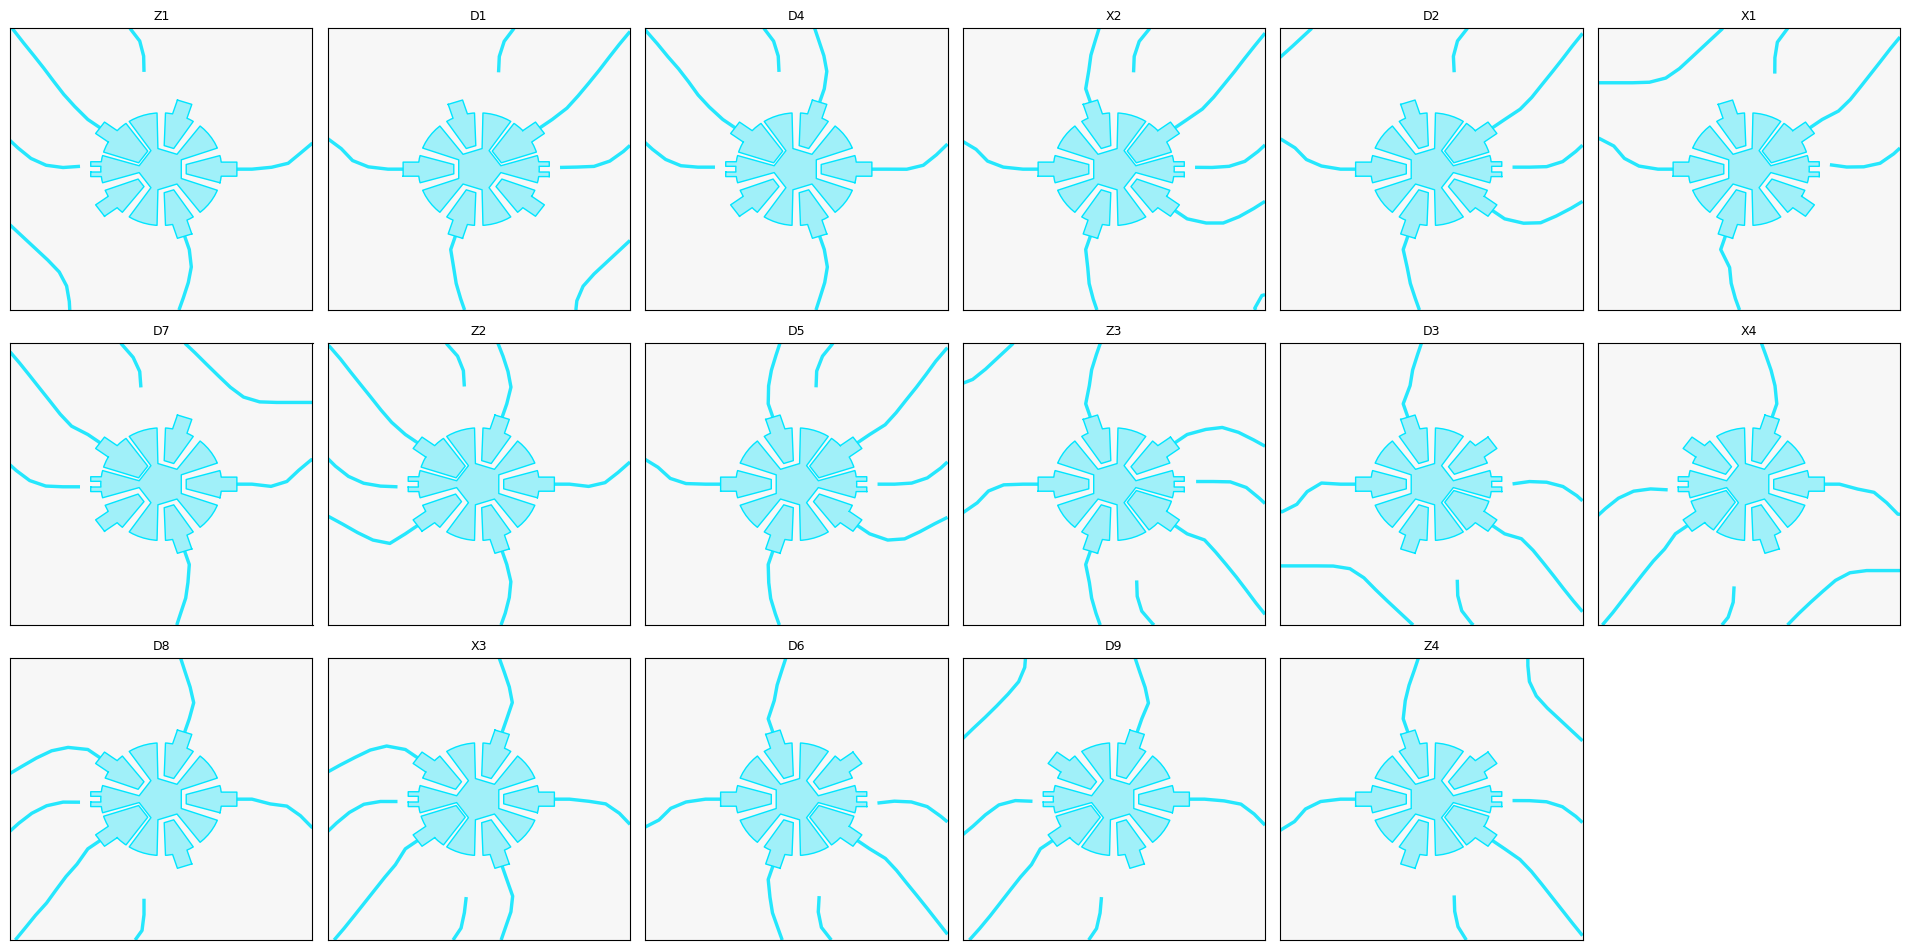

In [11]:
fig = inspect_sites(design, {q: list(p) for q, p in chip.QUBIT_POS.items()}, radius=0.4)
plt.show()

### Export to GDS

The mask file, ready for a layout viewer such as KLayout.

In [12]:
import logging

out = Path(tempfile.gettempdir()) / "wallraff_17q.gds"
gds = design.renderers.gds
gds.options.short_segments_to_not_fillet = "False"

# The renderer logs notes on cheesing and junction-cell files that do not
# apply to this chip; show errors only while exporting.
level = qm.logger.level
qm.logger.setLevel(logging.ERROR)
try:
    gds.export_to_gds(str(out))
finally:
    qm.logger.setLevel(level)
print(f"{out.name}: {out.stat().st_size / 1e6:.1f} MB")

wallraff_17q.gds: 3.9 MB


## 🧪 Play with it

The design is live: change an option, rebuild, and check again.

**Tune a Purcell coupler.** The filter–feedline coupling of qubit `D5` is set by the length of its `CapFingerInFrame`. Make it longer and look at it before and after.

frame_length: 153.0um


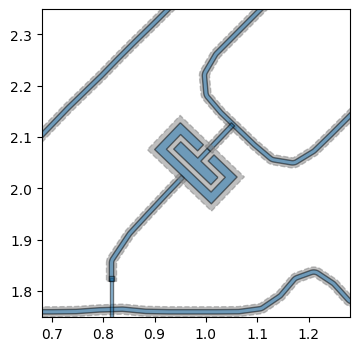

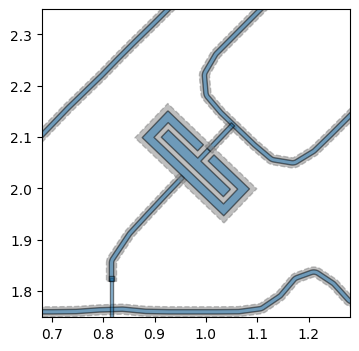

348 components


1 finding(s) from 11 rule(s): 0 error(s), 1 warning(s)
  [warning] ground-continuity: ground plane on layer 1 is split into 9 disconnected regions (mm^2: 169.756, 2.617, 2.602, 2.597, ...); confirm airbridges or vias tie them together -- this check sees only same-layer metal  @ (1.1888, 0.8377)


In [13]:
cap = design.components["PUCAP_D5"]
x, y = float(cap.options.pos_x[:-2]), float(cap.options.pos_y[:-2])
win = dict(xlim=(x - 0.3, x + 0.3), ylim=(y - 0.3, y + 0.3), size=4)

print("frame_length:", cap.options.frame_length)
show(design, **win)

cap.options.frame_length = "220um"
cap.rebuild()
show(design, **win)
check(design)

**Break it on purpose.** Delete the open termination at the end of `D5`'s drive line. Nothing looks different at chip scale, but the line now ends against the ground plane — a short on the wafer. The check catches it and says where.

In [14]:
design.delete_component("DRIVEOPEN_D5")
check(design)

347 components


2 finding(s) from 11 rule(s): 0 error(s), 2 warning(s)
  [warning] ground-continuity: ground plane on layer 1 is split into 9 disconnected regions (mm^2: 169.756, 2.617, 2.602, 2.597, ...); confirm airbridges or vias tie them together -- this check sees only same-layer metal  @ (1.1888, 0.8377)
  [warning] dangling-end: DRIVE_D5_3.end is an unconnected path end: it butts the ground plane and fabricates as a short -- connect it, or terminate it with OpenToGround/ShortToGround  @ (0.0524, 0.2751)


**More to try**

- Rebuild the whole chip with a different coplanar cross-section (it is 8.5 µm center conductor, 5.5 µm gap): `chip.CPW.update(width="10um", gap="6um")`, then `design = chip.build()`, `gui.set_design(design)` and `check(design)`.
- In the desktop GUI, click through the components by name and edit an option in the component panel; rerun `check(design)` to see what changed.
- Cut out one unit cell — two qubits and their coupler — and mesh it for a capacitance simulation.
- Ask an AI agent with the [`chip-design`](https://github.com/qiskit-community/qiskit-metal/blob/main/.claude/skills/chip-design/SKILL.md) skill to design a new chip from a specification of your own — say, a smaller surface-code patch with your frequency plan — and check it the same way.

## Known issues — this is a mockup

- **Crossovers.** Where one line crosses another, the device uses integrated crossovers. Here each crossing is an `Airbridge` over a cut in the line: electrically a crossing, but not the same structure.
- **Junctions.** `StarQubit` draws a single junction where the device has a SQUID. It sits on the island arm facing the flux line, as on the device; the flux line ends in a short just outside the pocket beside it.
- **Pad angles** follow a regular 72° pattern; the device's are within 6° of it.
- **Dimensions finer than the images** (about 7.5 µm per pixel) are chosen, not measured: the coplanar center conductor and gap (8.5 and 5.5 µm, from the measured 14 µm total at 50 Ω on silicon) and the capacitor gaps (10 µm, consistent with every measured spacing).
- **Airbridges** are placed only where one line crosses another; the ground-strapping bridges along the lines are not.

## Acknowledgements

The device design is by the Quantum Device Lab, ETH Zurich (A. Wallraff). We thank Andreas Wallraff and the team for sharing it openly through the [lecture slides](https://polybox.ethz.ch/index.php/s/CnsHoKWW6xQKZAA) and talks ([1](https://www.youtube.com/watch?v=floIDDd6ZXA), [2](https://www.youtube.com/watch?v=CgNz4wsD0oI), [3](https://www.youtube.com/watch?v=0r1YPMcmuFU), the last at the Quantum Device Workshop), which made this reconstruction possible. The Quantum Metal layout was rebuilt by AI agents working with Quantum Metal, reviewed stage by stage.

## References

**The device and its experiments**

1. S. Krinner, N. Lacroix, A. Remm *et al.*, "Realizing repeated quantum error correction in a distance-three surface code," *Nature* **605**, 669–674 (2022). [doi:10.1038/s41586-022-04566-8](https://doi.org/10.1038/s41586-022-04566-8)
2. I. Besedin, M. Kerschbaum, J. Knoll *et al.*, "Lattice surgery realized on two distance-three repetition codes with superconducting qubits," *Nature Physics* **22**, 189–194 (2026). [doi:10.1038/s41567-025-03090-6](https://doi.org/10.1038/s41567-025-03090-6) · [arXiv:2501.04612](https://arxiv.org/abs/2501.04612)
3. C. K. Andersen, A. Remm, S. Lazar *et al.*, "Repeated quantum error detection in a surface code," *Nature Physics* **16**, 875–880 (2020). [doi:10.1038/s41567-020-0920-y](https://doi.org/10.1038/s41567-020-0920-y)

**Readout and Purcell filters**

4. J. Heinsoo, C. K. Andersen, A. Remm *et al.*, "Rapid high-fidelity multiplexed readout of superconducting qubits," *Phys. Rev. Applied* **10**, 034040 (2018). [doi:10.1103/PhysRevApplied.10.034040](https://doi.org/10.1103/PhysRevApplied.10.034040)
5. T. Walter, P. Kurpiers, S. Gasparinetti *et al.*, "Rapid high-fidelity single-shot dispersive readout of superconducting qubits," *Phys. Rev. Applied* **7**, 054020 (2017). [doi:10.1103/PhysRevApplied.7.054020](https://doi.org/10.1103/PhysRevApplied.7.054020)

**Background**

6. A. G. Fowler, M. Mariantoni, J. M. Martinis, A. N. Cleland, "Surface codes: Towards practical large-scale quantum computation," *Phys. Rev. A* **86**, 032324 (2012). [doi:10.1103/PhysRevA.86.032324](https://doi.org/10.1103/PhysRevA.86.032324)
7. J. Koch, T. M. Yu, J. Gambetta *et al.*, "Charge-insensitive qubit design derived from the Cooper pair box," *Phys. Rev. A* **76**, 042319 (2007). [doi:10.1103/PhysRevA.76.042319](https://doi.org/10.1103/PhysRevA.76.042319)
8. A. Blais, A. L. Grimsmo, S. M. Girvin, A. Wallraff, "Circuit quantum electrodynamics," *Rev. Mod. Phys.* **93**, 025005 (2021). [doi:10.1103/RevModPhys.93.025005](https://doi.org/10.1103/RevModPhys.93.025005)
9. S. Krinner, S. Storz, P. Kurpiers *et al.*, "Engineering cryogenic setups for 100-qubit scale superconducting circuit systems," *EPJ Quantum Technology* **6**, 2 (2019). [doi:10.1140/epjqt/s40507-019-0072-0](https://doi.org/10.1140/epjqt/s40507-019-0072-0)

**Sources for the geometry**

10. A. Wallraff, lecture slides and talks, Quantum Device Lab, ETH Zurich: [slides](https://polybox.ethz.ch/index.php/s/CnsHoKWW6xQKZAA); talks [1](https://www.youtube.com/watch?v=floIDDd6ZXA), [2](https://www.youtube.com/watch?v=CgNz4wsD0oI), [3](https://www.youtube.com/watch?v=0r1YPMcmuFU) (Quantum Device Workshop).